In [2]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews

import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


In [3]:
# Load reviews and labels
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffle data
random.shuffle(documents)

texts = [doc for doc, _ in documents]
labels = [label for _, label in documents]


In [4]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(texts)
y = labels


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [10]:
import pickle

# Save model and vectorizer
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("✅ Model and vectorizer saved!")

✅ Model and vectorizer saved!


In [7]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8575

Classification Report:
               precision    recall  f1-score   support

         neg       0.83      0.88      0.86       195
         pos       0.88      0.83      0.86       205

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [8]:
sample_review = ["This movie was absolutely amazing! I loved the acting."]
sample_vector = vectorizer.transform(sample_review)
prediction = model.predict(sample_vector)
print("Prediction:", prediction[0])


Prediction: pos


In [11]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cf = confusion_matrix(y_test, y_pred)

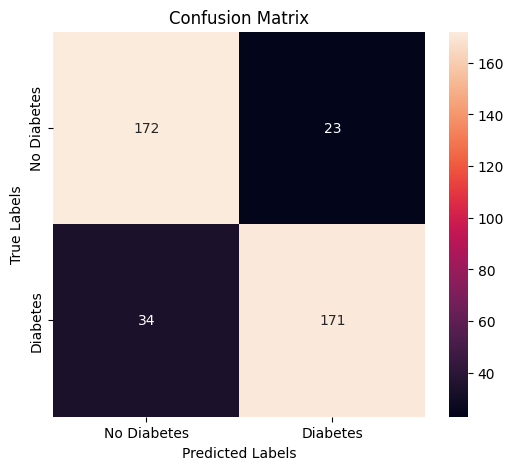

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cf, annot=True, fmt='d', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()